# 03 — Per-class P1D from raw spectra + catalog

The per-class P1D (`p1d_per_class.h5`) is the principal *clustering*
statistic this dataset provides.  It contains four 1-dimensional power
spectra:

| Key | Meaning |
|---|---|
| `P_clean`        | P1D averaged over sightlines with **no** HCD (clean forest) |
| `P_LLS_only`     | P1D averaged over sightlines whose highest-class absorber is an LLS |
| `P_subDLA_only`  | P1D averaged over sightlines whose highest-class absorber is a subDLA |
| `P_DLA_only`     | P1D averaged over sightlines whose highest-class absorber is a DLA |

These are the **Rogers et al. 2018** per-class templates.  Each P1D uses
its own subset's mean flux for δF normalisation — you'll see why in §3.

By the end of this notebook you will:

1. Load and inspect `p1d_per_class.h5`.
2. Plot the four templates and the canonical Rogers ratio
   `P_DLA_only / P_clean`.
3. Recompute `P_DLA_only` from raw spectra + catalog on a small
   subsample using `hcd_analysis.p1d.compute_p1d_per_class` and confirm
   it matches the cached version.

This is the longest of the five notebooks because it ends at the
boundary of the emulator work.

**Why per-class P1D matters.**  The observed forest P1D mixes
contributions from the smooth IGM and from HCDs.  In a single global
P1D you cannot tell the two apart; a per-class decomposition isolates
the HCD contribution into four well-defined templates that depend on
NHI threshold rather than on cosmology.  The Rogers et al. 2018 fit then
parameterises these templates with a small (4-parameter) α-model that
the upstream Lyα emulator can absorb.  Producing these four templates
for every (sim, snap) in the suite — and tracking how they vary with
the 9 PRIYA parameters — is the central job of this dataset.

**Units summary.**  Throughout this notebook:

* `k` is the cyclic wavenumber along the sightline, **units s/km**
  (cyclic means `k = m / L_v`, where `L_v` is the box size in velocity
  units; angular `k_ang = 2π k` lives in rad·s/km and is what the PRIYA
  emulator plots).
* `P1D(k)` has units **km/s** (`δF` is dimensionless, the FFT picks up
  one power of `dv`).
* `⟨F⟩` is dimensionless (transmitted-fraction).


In [1]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
import h5py

DATA_ROOT    = Path('/nfs/turbo/umor-yueyingn/mfho/emu_full')
HCD_OUT_ROOT = Path('/scratch/cavestru_root/cavestru0/mfho/hcd_outputs')
SIM  = 'ns0.81Ap1.6e-09herei3.59heref2.79alphaq1.71hub0.668omegamh20.145hireionz7.92bhfeedback0.0333'
SNAP = 22
SNAP_DIR = HCD_OUT_ROOT / SIM / f'snap_{SNAP:03d}'
RAW_FILE = DATA_ROOT / SIM / 'output' / f'SPECTRA_{SNAP:03d}' / 'lya_forest_spectra_grid_480.hdf5'

with open(SNAP_DIR / 'meta.json') as f:
    meta = json.load(f)
print(f'sim={SIM[:50]}…  snap={SNAP}  z={meta["z"]}')


sim=ns0.81Ap1.6e-09herei3.59heref2.79alphaq1.71hub0.66…  snap=22  z=2.0


In [2]:
# --- Tutorial figure-style preamble (auto-generated by _build_notebooks.py) ---
import matplotlib.pyplot as plt
from pathlib import Path as _Path

# Consistent style across all tutorial notebooks.
plt.rcParams.update({
    "font.size":        12,
    "axes.titlesize":   14,
    "axes.labelsize":   12,
    "xtick.labelsize":  11,
    "ytick.labelsize":  11,
    "legend.fontsize":  10,
    "figure.dpi":       110,
    "savefig.dpi":      200,
    "savefig.bbox":     "tight",
    "lines.linewidth":  1.4,
})

# Figures saved by this notebook land here.  Path is relative to the
# notebooks/tutorials/ directory; we resolve from __file__ for nbconvert
# and from cwd for an interactive Jupyter run.
try:
    _NB_DIR = _Path(__file__).parent
except NameError:
    _NB_DIR = _Path.cwd()
_FIG_DIR = _NB_DIR / "figures"
_FIG_DIR.mkdir(parents=True, exist_ok=True)


def save_fig(fig, name, *, tight=True):
    """Apply tight_layout, save to figures/<name>.png at dpi=200, return path.

    name should look like ``NB02_cddf_vs_ho21`` (no extension); the function
    appends ``.png`` and writes into ``notebooks/tutorials/figures/``.
    """
    if tight:
        fig.tight_layout()
    out = _FIG_DIR / f"{name}.png"
    fig.savefig(out, dpi=200)
    return out


## 1. The cached file

`p1d_per_class.h5` is a small HDF5 with one `k` array, four power
arrays, four mean-flux scalars, four sightline counts, and ~10 self-
documenting attributes at the file root.  Run `f.visititems(print)` if
you ever forget the schema.


In [3]:
with h5py.File(SNAP_DIR / 'p1d_per_class.h5', 'r') as f:
    print('--- root attributes ---')
    for k, v in f.attrs.items():
        print(f'  {k}: {v}')
    print()
    print('--- datasets ---')
    f.visititems(lambda n, o: isinstance(o, h5py.Dataset)
                 and print(f'  {n}: shape={o.shape} dtype={o.dtype}'))


--- root attributes ---
  description: Per-class subset P1D templates. Each class is the 'highest' absorber class on a sightline (DLA beats subDLA beats LLS). Rogers+2018 template P_total/P_forest = P_<class>_only / P_clean.
  dv_kms: 10.00505191229706
  fast_mode: True
  k_convention: cyclic (numpy rfftfreq); PRIYA_angular_k = 2*pi*this
  mean_F_convention: per-subset <F>; δF = F/<F>_subset - 1
  min_log_nhi: 17.2
  mode: LF
  nbins: 1228
  patch_script: patch_per_class_p1d.py
  sim_name: ns0.81Ap1.6e-09herei3.59heref2.79alphaq1.71hub0.668omegamh20.145hireionz7.92bhfeedback0.0333
  snap: 22
  source_module: hcd_analysis.p1d.compute_p1d_per_class
  tau_threshold: 100.0
  z: 2.0

--- datasets ---
  P_DLA_only: shape=(615,) dtype=float64
  P_LLS_only: shape=(615,) dtype=float64
  P_clean: shape=(615,) dtype=float64
  P_subDLA_only: shape=(615,) dtype=float64
  k: shape=(615,) dtype=float64
  mean_F_DLA: shape=() dtype=float64
  mean_F_LLS: shape=() dtype=float64
  mean_F_clean: shape=() 

In [4]:
with h5py.File(SNAP_DIR / 'p1d_per_class.h5', 'r') as f:
    k       = f['k'][:]
    p_clean = f['P_clean'][:]
    p_lls   = f['P_LLS_only'][:]
    p_sub   = f['P_subDLA_only'][:]
    p_dla   = f['P_DLA_only'][:]
    n_clean = int(f['n_sightlines_clean'][()])
    n_lls   = int(f['n_sightlines_LLS'][()])
    n_sub   = int(f['n_sightlines_subDLA'][()])
    n_dla   = int(f['n_sightlines_DLA'][()])
    n_total = int(f['n_total'][()])
    mF_clean = float(f['mean_F_clean'][()])
    mF_dla   = float(f['mean_F_DLA'][()])

print(f'k grid: len={len(k)}  k_min={k[1]:.4g} (k[0]=0 is DC)  k_max={k[-1]:.4g}  s/km   (cyclic, on-disk)')
print(f'sightlines: total={n_total:,}  clean={n_clean:,}  LLS={n_lls:,}  subDLA={n_sub:,}  DLA={n_dla:,}')
print(f'<F>_clean = {mF_clean:.4f}    <F>_DLA = {mF_dla:.4f}')


k grid: len=615  k_min=8.139e-05 (k[0]=0 is DC)  k_max=0.04997  s/km   (cyclic, on-disk)
sightlines: total=691,200  clean=615,627  LLS=49,886  subDLA=16,840  DLA=8,847
<F>_clean = 0.8563    <F>_DLA = 0.5483


## 1b. The k convention used throughout this project: **angular k**

The HDF5 file stores `k` from `numpy.fft.rfftfreq`, which is **cyclic**
wavenumber `k_cyc = m / L_v` in units of `s/km`.  The standard
convention for PRIYA Lyα analyses (Bird+2023, Rogers+2018, all
downstream emulator inputs) is the **angular** wavenumber

$$
k_{\rm ang} \;=\; 2\pi\, k_{\rm cyc}
\qquad(\text{units: } {\rm rad}\cdot s/km).
$$

We adopt the same convention here.  From this point on in NB03 — and
in the in-repo emulator cache (`hcd_analysis/_emulator_data/observables.h5`,
see §4) — every plotted and stored `k` is `k_ang`.  When you load
`p1d_per_class.h5` directly, multiply the on-disk `k` by `2π` to get
into the project convention.  The P1D *values* are numerically
unchanged by this relabel (the prefactor cancels because of how
Parseval's theorem partitions across the two conventions); only the
x-axis shifts.


In [5]:
# From here on, work in angular k_ang = 2*pi * k_cyc throughout.
k_ang = 2.0 * np.pi * k        # rad·s/km


## 2. Plot the four templates

The four P1Ds are very close to each other in shape but differ in
amplitude — DLA-bearing sightlines have lower mean flux than clean ones,
which (after δF normalisation by the *subset's own* mean flux) shifts
the P1D up.  This is the Rogers convention:

```
δF_subset(v) = F(v) / <F>_subset − 1
P_subset(k)  = ⟨ |FFT[δF_subset]|² ⟩  / L
```

Importantly, `<F>_subset` is **not** the global mean flux.  Using the
per-subset mean flux is what makes the ratio `P_<class>_only / P_clean`
a clean *template* that depends only on HCD properties, not on the
forest amplitude.


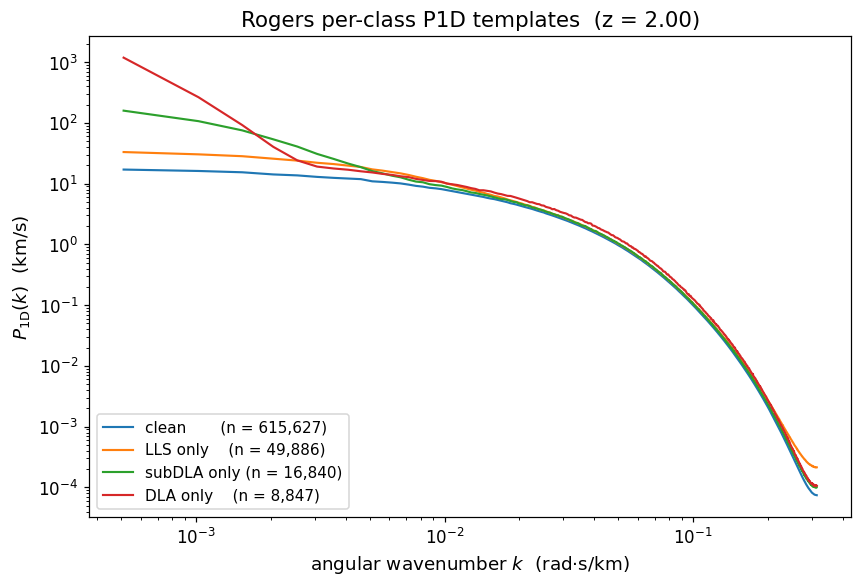

In [6]:
fig, ax = plt.subplots(figsize=(8, 5.5))

for arr, lbl, c in [(p_clean, f'clean       (n = {n_clean:,})',  'C0'),
                    (p_lls,   f'LLS only    (n = {n_lls:,})',    'C1'),
                    (p_sub,   f'subDLA only (n = {n_sub:,})',    'C2'),
                    (p_dla,   f'DLA only    (n = {n_dla:,})',    'C3')]:
    sel = (k_ang > 0) & (arr > 0)
    ax.loglog(k_ang[sel], arr[sel], '-', label=lbl, color=c)

ax.set_xlabel(r'angular wavenumber $k$  (rad$\cdot$s/km)')
ax.set_ylabel(r'$P_{1\rm D}(k)$  (km/s)')
ax.set_title(f'Rogers per-class P1D templates  (z = {meta["z"]:.2f})')
ax.legend(loc='lower left')
save_fig(fig, 'NB03_per_class_p1d')
plt.show()


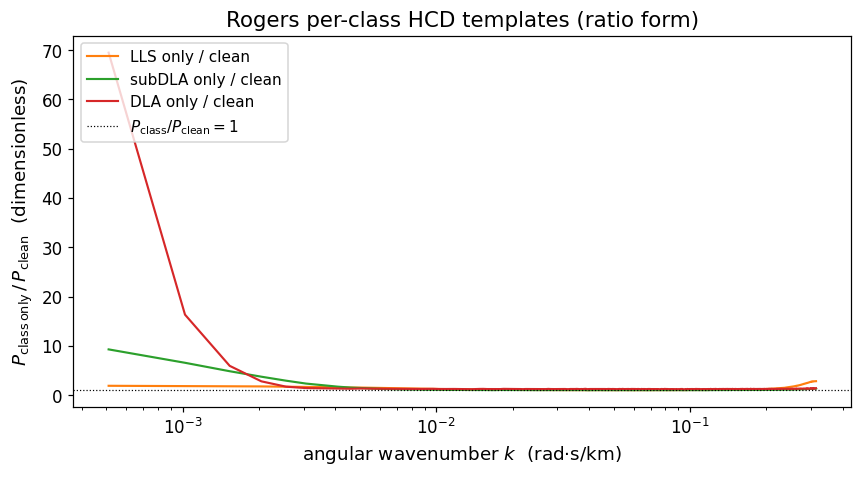

In [7]:
# The Rogers-style template ratio: P_<class> / P_clean
fig, ax = plt.subplots(figsize=(8, 4.5))
sel = (k_ang > 0) & (p_clean > 0)

for arr, lbl, c in [(p_lls, 'LLS only / clean',    'C1'),
                    (p_sub, 'subDLA only / clean', 'C2'),
                    (p_dla, 'DLA only / clean',    'C3')]:
    ax.semilogx(k_ang[sel], arr[sel] / p_clean[sel], '-', label=lbl, color=c)

ax.axhline(1.0, color='k', linestyle=':', linewidth=0.8, label=r'$P_{\rm class}/P_{\rm clean} = 1$')
ax.set_xlabel(r'angular wavenumber $k$  (rad$\cdot$s/km)')
ax.set_ylabel(r'$P_{\rm class\,only}\,/\,P_{\rm clean}$  (dimensionless)')
ax.set_title('Rogers per-class HCD templates (ratio form)')
ax.legend(loc='upper left')
save_fig(fig, 'NB03_per_class_p1d_ratio')
plt.show()


**What you should see.**  The DLA template is well above 1 at all k —
adding even one DLA to a sightline boosts its δF variance enormously.
The subDLA template is a milder boost; the LLS template is closer to
unity (small NHI → small effect).  The downturn at low k is the
finite-box / DC-removal regime; the upturn at high k is where the FFT
starts seeing the absorber's velocity profile directly.

These three ratio curves are exactly what the upstream Lyα emulator
fits with the Rogers α-template, and what our two-headed emulator
will need to learn as a function of the 9-D parameter vector.


## 3. Recomputing P_DLA_only from scratch

Now the round-trip exercise.  We will:

1. Load the catalog (so we know which sightlines are DLA-bearing).
2. Stream the raw `tau` array, classify each sightline, and accumulate a
   P1D per class.
3. Use `hcd_analysis.p1d.compute_p1d_per_class` to do the work.

A full pass over 691 200 sightlines × 1141 pixels takes a couple of
minutes per snap on a Great Lakes login node.  For the tutorial we cap
at `n_skewers = 30000` (≈4 % of the sim) and verify shape + low-k
agreement; the high-k tail will be noisier on the subsample but the
template shape should be correct.


In [8]:
from hcd_analysis.catalog import AbsorberCatalog
from hcd_analysis.p1d     import compute_p1d_per_class

ac = AbsorberCatalog.load_npz(SNAP_DIR / 'catalog.npz')

# Use the same nbins / dv_kms as the cached file (these are sim-snap-specific).
nbins  = int(meta['nbins'])
dv_kms = float(meta['dv_kms'])

result = compute_p1d_per_class(
    RAW_FILE,
    nbins=nbins,
    dv_kms=dv_kms,
    catalog=ac,
    n_skewers=30_000,    # subsample for the tutorial; full = 691200
)

print('Returned keys:', sorted(result.keys()))
print('k shape       :', result['k'].shape)
print('P_DLA_only    :', result['P_DLA_only'].shape)
print('mean_F_DLA    :', result['mean_F_DLA'])
print('n_sightlines_DLA (subsample):', result['n_sightlines_DLA'])


Returned keys: ['P_DLA_only', 'P_LLS_only', 'P_clean', 'P_subDLA_only', 'k', 'mean_F_DLA', 'mean_F_LLS', 'mean_F_clean', 'mean_F_subDLA', 'n_sightlines_DLA', 'n_sightlines_LLS', 'n_sightlines_clean', 'n_sightlines_subDLA', 'n_total']
k shape       : (615,)
P_DLA_only    : (615,)
mean_F_DLA    : 0.535739830758176
n_sightlines_DLA (subsample): 460


**Caveats of running on a subsample.**  Because the subsample mostly
contains low-NHI sightlines (DLAs are rare — about 1 in 70 sightlines),
`mean_F_DLA` and the DLA P1D have *much* larger sample-noise than the
cached version.  The clean / LLS / subDLA P1Ds will be in much better
agreement.  Plot the cached and recomputed `P_clean` together so you
can see the agreement at low/intermediate k:


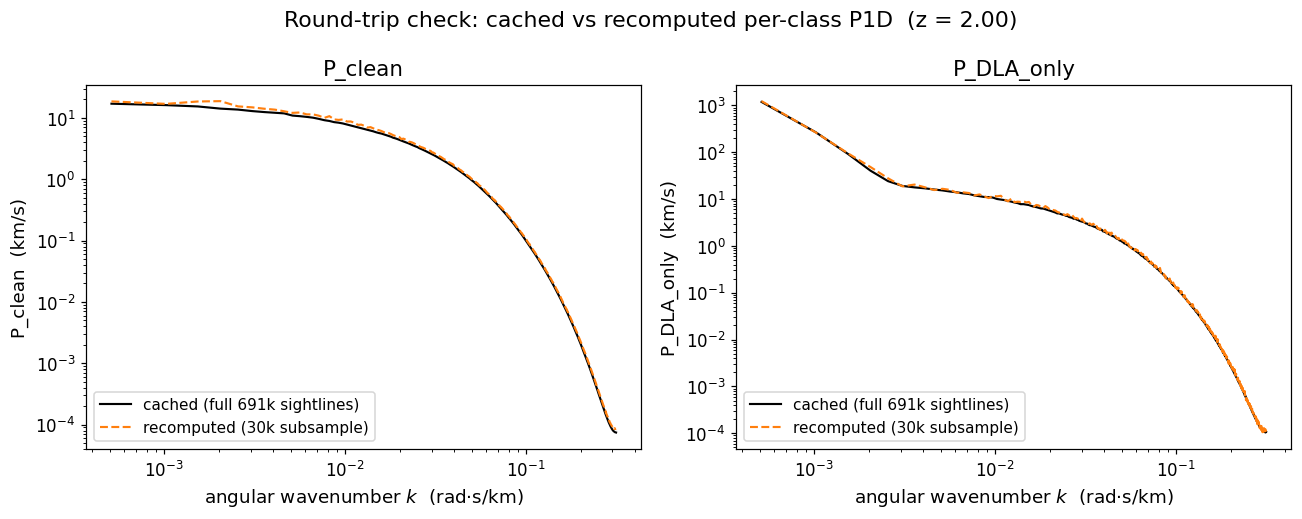

In [9]:
k_re       = 2.0 * np.pi * result['k']        # convert to angular up-front
p_clean_re = result['P_clean']
p_dla_re   = result['P_DLA_only']

# Same k-grid because nbins and dv_kms match.  Sanity-check that.
assert k_re.shape == k_ang.shape, 'k-grid mismatch — nbins must differ'
assert np.allclose(k_re, k_ang, rtol=1e-12, atol=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for ax_, cached, sub, lbl in zip(axes,
                                 (p_clean, p_dla),
                                 (p_clean_re, p_dla_re),
                                 ('P_clean  (km/s)', 'P_DLA_only  (km/s)')):
    sel = (k_ang > 0) & (cached > 0)
    ax_.loglog(k_ang[sel], cached[sel], 'k-', label='cached (full 691k sightlines)')
    sel2 = (k_ang > 0) & (sub > 0)
    ax_.loglog(k_ang[sel2], sub[sel2], 'C1--', label='recomputed (30k subsample)')
    ax_.set_xlabel(r'angular wavenumber $k$  (rad$\cdot$s/km)')
    ax_.set_ylabel(lbl)
    ax_.set_title(lbl.split(' ')[0])
    ax_.legend(loc='lower left')

fig.suptitle(f'Round-trip check: cached vs recomputed per-class P1D  (z = {meta["z"]:.2f})')
save_fig(fig, 'NB03_round_trip_cached_vs_recomputed')
plt.show()


**What you should see.**  `P_clean` agrees nearly perfectly across all k
— ~26 000 of the 30 000 subsampled sightlines are clean.  `P_DLA_only`
agrees on the broad shape but the recomputed curve is noisier and the
amplitude can be off by 10–20% at the high-k tail because only a few
hundred DLA sightlines are in the subsample.  This is expected; if you
have the patience for ~3 minutes of CPU you can rerun with
`n_skewers=None` to reproduce the cached values to floating-point
precision.

## 4. The mean-flux dimension (preview of the emulator work)

Each cached `p1d_per_class.h5` is at a single mean flux — the sim's
*natural* `<F>` at that snapshot's redshift.  Real Lyα analyses observe
the forest at many different `τ_eff` values (driven by UVB and IGM
temperature uncertainties), so a P1D emulator needs a **mean-flux
dimension** in addition to the 9 cosmological parameters.

The standard way to add this dimension is to rescale `tau → α · tau`
post-hoc and recompute `F = exp(−α · tau)`, sweeping α to cover the
desired `τ_eff` range.  We will add this rescaling step in phase 1 of
the emulator work — it requires touching the raw spectra again, not
the cached per-class P1D.

For now, just be aware that **`P_DLA_only` on disk is at one specific
`<F>`** and that the emulator work will need to broaden it into a
2-argument function `P_DLA_only(params, τ_eff)`.


## Suggested student exercises

1. **Full-sim reproduction.**  Drop `n_skewers=30000` and rerun on the
   full file.  It will take a couple of minutes; the recomputed
   `P_DLA_only` should match the cached values to floating-point
   precision.
2. **Different NHI threshold.**  In `compute_p1d_per_class`, the
   highest-class label uses the standard 17.2 / 19.0 / 20.3 boundaries.
   Modify the function (or wrap it) to use 17.5 / 19.5 / 20.5 and see
   how the four templates shift.  This is exactly the kind of ablation
   we run when calibrating the emulator threshold choices.
3. **Parseval check.**  Pick one clean sightline, compute its δF and
   FFT, and verify Parseval's theorem.  Conventions used by
   `compute_p1d_per_class`:

   * Use `np.fft.rfft` on `delta_F = F/⟨F⟩ − 1` (real input → one-sided
     k array via `np.fft.rfftfreq(nbins, d=dv_kms)`, cyclic units).
     Multiply by `dv_kms` so the result has units of velocity, then
     square the modulus and divide by the box length `L = nbins * dv_kms`:
     `P(k) = (dv * |rfft(δF)|)² / L`.
   * Sum over k with a **factor-of-two boost** on the non-DC and
     non-Nyquist bins (because rfft returned the one-sided spectrum
     and `|F̃(−k)|² = |F̃(k)|²`):
     `var_from_P = (2/L) * sum(P[1:-1]) * dk + (P[0]+P[-1])/L * dk`
     where `dk = 1/L` (cyclic) or equivalently `(1/L) * (P[0]+P[-1] + 2*P[1:-1].sum())`.
   * Verify it equals `np.var(delta_F, ddof=0)` to ~1e-12 relative
     precision on a clean sightline.  Any mismatch points at a missing
     `dv`/`L` factor or a wrong rfft-vs-fft convention.

## Where to next

You're now equipped to read every observable this dataset produces.  The
next milestone is **phase 1 of the HCD emulator work**: a single in-repo
HDF5 cache that stacks the per-(sim, snap) observables across all 1076
outputs onto a shared (angular) k-grid and a shared NHI-grid.  That
cache lives at `hcd_analysis/_emulator_data/observables.h5` (gitignored;
rebuild with `python3 scripts/build_emulator_cache.py --spot-check`) and
the row schema follows §1b of this notebook: `k_target` is angular,
the per-class P1D arrays are pre-interpolated onto it, and rows missing
the high-k tail (because their native Nyquist is below the top bin)
are NaN-masked rather than extrapolated.

If you want to extend any of this, see the **F-track projects**
("Emulator scaffolding") in `notebooks/tutorials/STUDENT_PROJECTS.md` —
project **F1** is in particular a direct continuation of this notebook
(multi-sim shared k-grid choice + interpolation policy).
